In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import offsetbox

import seaborn as sns

%matplotlib inline

In [3]:

df = pd.read_csv('../Datos/ip_a_procesar.csv')

# para considerar la plataforma hago un dummy temporario

In [4]:
# para poder ver si la plataforma correlaciona con algo, la codificamos. 1- iOS, 0 - Android
df['plataforma'] = np.where(df.platform =='iOS',1,0)

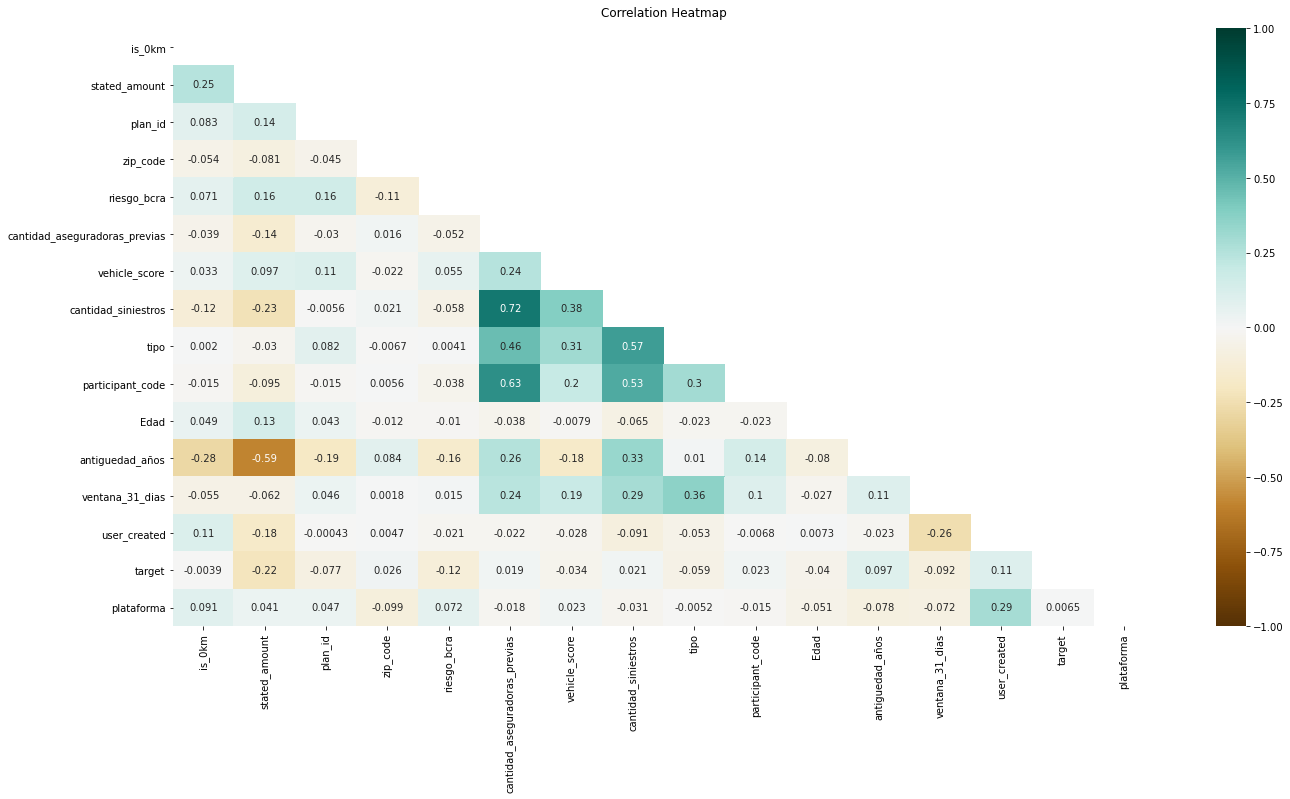

In [5]:
plt.figure(figsize=(22, 11))
mask = np.triu(np.ones_like(df.corr(), dtype=np.bool))
heatmap = sns.heatmap(df.corr(),mask=mask,vmax=1, vmin=-1,annot=True,cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);


#### de la correlación podemos observar relaciones evidentes entre variables como stated_amount y la antiguedad, o la cantidad de aseguradoras previas con la cantidad de siniestros, pero no hay ninguna relacion fuerte con nuestro target

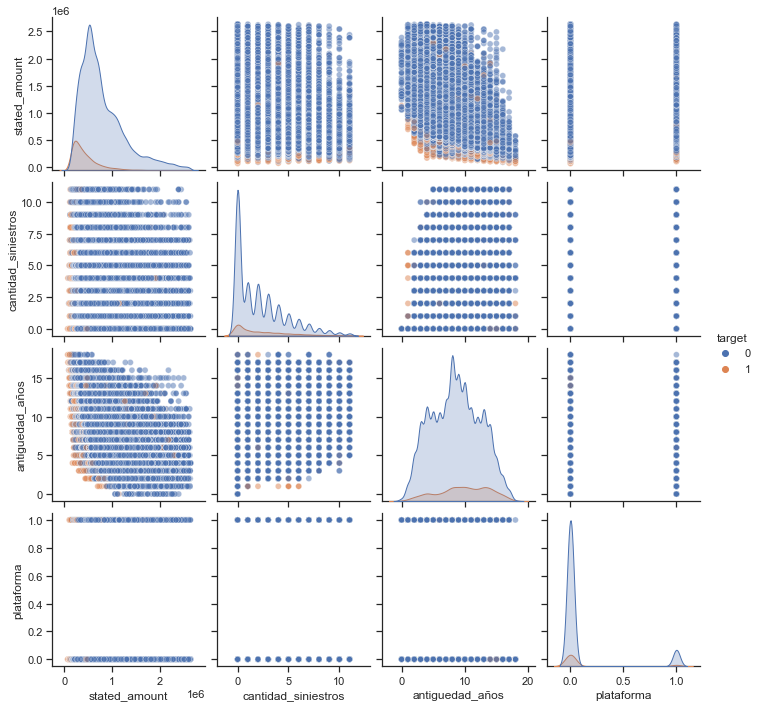

In [6]:
sns.set_theme(style="ticks")
columnas = ['stated_amount', 
           'cantidad_siniestros',   
           'antiguedad_años',
           'plataforma',
         
           'target']
sns.pairplot(df[columnas],hue='target',kind='scatter', corner=False,plot_kws={'alpha': 0.5})

#### del pairplot lo que podemos observar es que el 'Stated Amount va a servir para separar algo a aquellos que no van a cumplir el proceso, aunque la correlacion sea debil.

#### Vamos a analizar el comportamiento del stated_amount en relacion a otras variables

In [7]:
dfAn = df[df.target==1].groupby('plan_id').target.count().reset_index()
dfAc = df[df.target==0].groupby('plan_id').target.count().reset_index()

In [8]:
dfTo = df.groupby(['plan_id','target']).stated_amount.count().reset_index()

In [9]:
dfAvg = df.groupby(['plan_id','target']).stated_amount.mean().reset_index()

In [10]:
df.plan_id.value_counts(normalize=True)

4    0.624700
5    0.249564
2    0.086314
3    0.039422
Name: plan_id, dtype: float64

Text(0.5, 0, 'Id Plan')

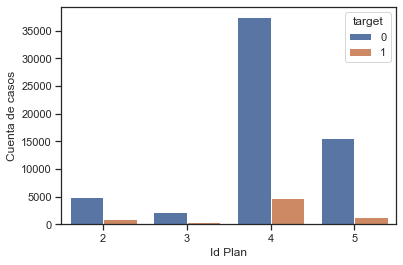

In [11]:
ax =sns.barplot(x='plan_id', y='stated_amount',hue='target',  data=dfTo)
ax.set_ylabel("Cuenta de casos")
ax.set_xlabel("Id Plan")


Text(0.5, 0, 'Id Plan')

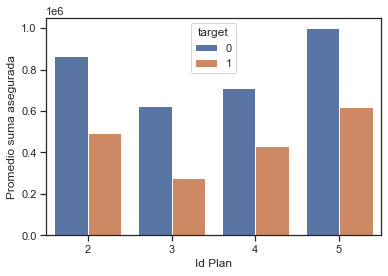

In [12]:
ax =sns.barplot(x='plan_id', y='stated_amount',hue='target',  data=dfAvg)
ax.set_ylabel("Promedio suma asegurada")
ax.set_xlabel("Id Plan")


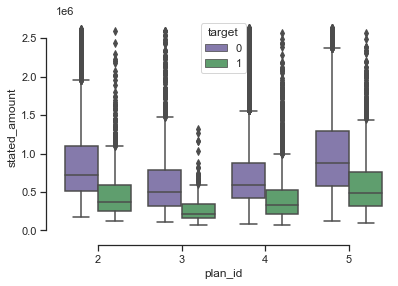

In [13]:
sns.set_theme(style="ticks")

sns.boxplot(x='plan_id', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

#### Plan_id es un buen candidato para separar el problema, ya que hay planes donde entre el monto del seguro y el tipo de plan se separa bien el target. Los planes 3,2 y 4 se separan bien con el importe....la 5 es mas complicada

In [14]:
df.riesgo_bcra.value_counts(normalize=True)

3.0    0.319732
4.0    0.178140
7.0    0.148354
6.0    0.147331
5.0    0.113867
8.0    0.078886
9.0    0.012007
0.0    0.001105
1.0    0.000577
Name: riesgo_bcra, dtype: float64

Text(0.5, 0, 'Riesgo BCRA')

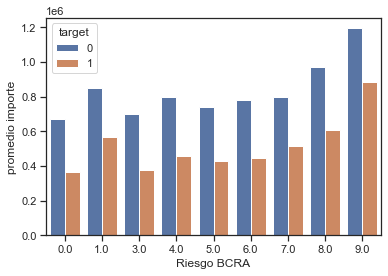

In [15]:
dfRAvg = df.groupby(['riesgo_bcra','target']).stated_amount.mean().reset_index()
ax =sns.barplot(x='riesgo_bcra', y='stated_amount',hue='target',  data=dfRAvg)
ax.set_ylabel("promedio importe")
ax.set_xlabel("Riesgo BCRA")


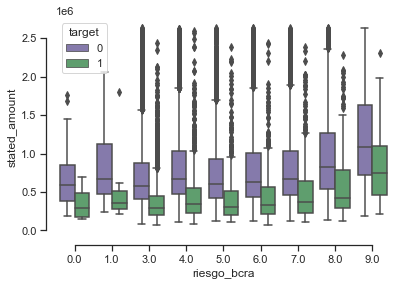

In [16]:
sns.set_theme(style="ticks")

sns.boxplot(x='riesgo_bcra', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

In [17]:
df.Sexo.value_counts(normalize=True)

m    0.771042
f    0.228958
Name: Sexo, dtype: float64

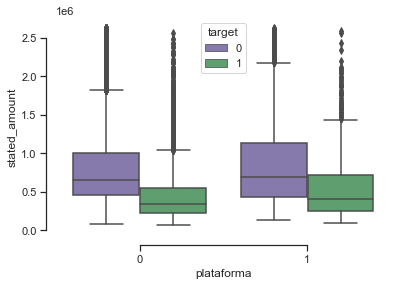

In [18]:
sns.set_theme(style="ticks")

sns.boxplot(x='plataforma', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

#### en el boxplot podemos comparar que aquellos que estan en Android (plataforma = 0) separan mejor el importe en las anulaciones que quienes estan en iOS

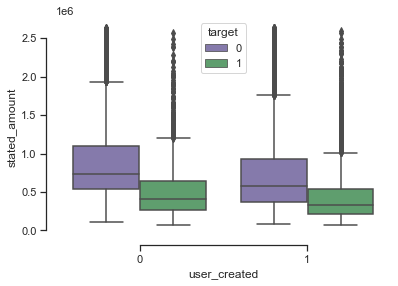

In [19]:
sns.set_theme(style="ticks")

sns.boxplot(x='user_created', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

####  Si el usuario no creo su identidad y ademas tiene una suma asegurada baja, es una anulacion, sin embargo para aquellos que si crean su identidad, aunque los valores bajos tienen mucha mas predisposicion a la anulacion, igual existe una minima superposicion de valores.

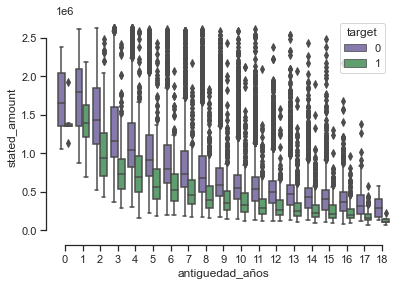

In [20]:
sns.set_theme(style="ticks")

sns.boxplot(x='antiguedad_años', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

##### seguimos conformando la influencia del importe asegurado y ademas es clara la relacion entre la antiguedad del vehiculo y la suma asegurada

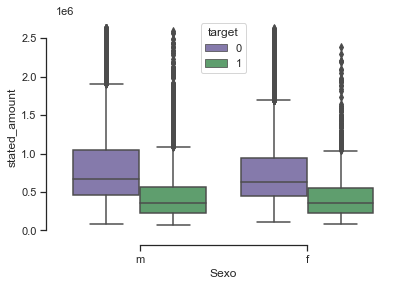

In [21]:
sns.set_theme(style="ticks")

sns.boxplot(x='Sexo', y='stated_amount',
            hue='target', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

##### hombres compran polizas un poco mas caras que mujeres, aunque la media es muy parecida

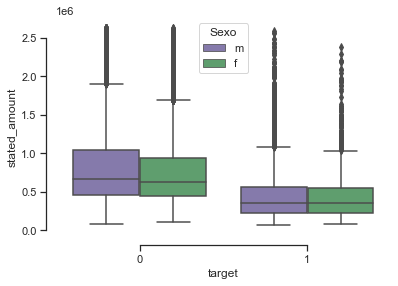

In [22]:
sns.set_theme(style="ticks")

sns.boxplot(x='target', y='stated_amount',
            hue='Sexo', palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

#### no parece que hubiera una importancia en el genero del tomador de la poliza

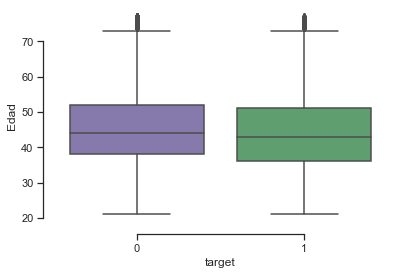

In [23]:
sns.set_theme(style="ticks")

sns.boxplot(x='target', y='Edad',
           palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

##### la Edad tampoco parece ser un buen clasificador

In [25]:
df.columns

Index(['is_0km', 'stated_amount', 'plan_id', 'zip_code', 'riesgo_bcra',
       'cantidad_aseguradoras_previas', 'vehicle_score', 'cantidad_siniestros',
       'tipo', 'participant_code', 'Edad', 'Sexo', 'antiguedad_años',
       'ventana_31_dias', 'tipo_de_vehiculo', 'platform', 'user_created',
       'target', 'plataforma'],
      dtype='object')

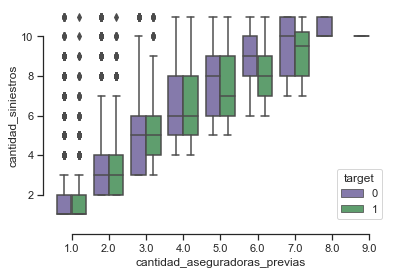

In [26]:
sns.set_theme(style="ticks")

sns.boxplot(x='cantidad_aseguradoras_previas', y='cantidad_siniestros',hue='target',
           palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)

- descartamos la relacion cantidad de aseguradoras previas con cantidad siniestros... 

### Vamos a ver si separando por tipo de documento e importe podemos segmentar el target
#### lo que haremos es calcular para el total del dataframe como se cruzan los importes medios de region para los targets 0 y 1

#### Comienzo con el dataset completo, todos los tipos de productos

In [331]:
# Separo el dataset entre anuladas y activas, y calculo las medias de sus areas.... 
print(df.shape)
anuladas = df[df.target==1]
activas = df[df.target==0]
anmean = anuladas.stated_amount.mean()
acmean = activas.stated_amount.mean()

(67602, 19)


In [327]:
#Cuales son las polizas en zona gris?
activas_bajas = activas[activas.stated_amount < anmean] # esta es la lista de polizas que estan activas pero su valor esta en el 
                                                        # rango de polizas anuladas

In [332]:
activas_bajas.shape # Polizas Activas con monto asegurado bajo, en area de anulacion.

(15077, 19)

In [333]:
#Cuantas altas en anuladas
anuladas_altas = anuladas[anuladas.stated_amount > acmean]

In [334]:
anuladas_altas.shape # La inversa, polizas anuladas con valores de prima en area de activas

(980, 19)

### Como ejemplo tomamos la poliza tipo 3 a ver que nos da.

In [343]:
anuladas_3 = anuladas[anuladas.plan_id == 3]
activas_3 = activas[activas.plan_id == 3]
print(anuladas_3.shape, activas_3.shape)

(391, 19) (2274, 19)


In [338]:
anmean_3 = anuladas_3.stated_amount.mean()
acmean_3 = activas_3.stated_amount.mean()

In [339]:
#Cuales son las polizas en zona gris?
activas_bajas_3 = activas_3[activas_3.stated_amount < anmean_3] # esta es la lista de polizas que estan activas pero su valor esta en el 
                                                        # rango de polizas anuladas

In [340]:
activas_bajas_3.shape # Polizas Activas con monto asegurado bajo, en area de anulacion.

(409, 19)

In [341]:
#Cuantas altas en anuladas
anuladas_altas_3 = anuladas_3[anuladas_3.stated_amount > acmean_3]

In [342]:
anuladas_altas_3.shape # La inversa, polizas anuladas con valores de prima en area de activas

(23, 19)

### Si modelamos por plan_id tenemos una buena posiblidad de dar mejores resultados que todo el dataset completo? vemos que sobre un total de 2665 polizas hay "confusion" en 23 que serian falsos negativos y en 409 en falso positivo. Si no le acertara en la clasificacion en nada, y mandara todas a sus clases naturales solo por el promedio del monto asegurado , tendria un recall de 1 - 0.0556 es decir 0.9444 

#### conclusion, vamos a hacer clasificaciones por tipo de poliza contratada, comparando contra un modelo que incluya todas las pólizas